# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
!bash scripts/datasets/get_datasets.sh

--2026-04-19 23:02:53--  http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 

128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  30.1MB/s    in 6.0s    

2026-04-19 23:03:00 (27.1 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [3]:
cifar10_dir = 'cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

/workspaces/AIT_Labs_6401_SurkovaAS/lab_1-2/scripts/data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



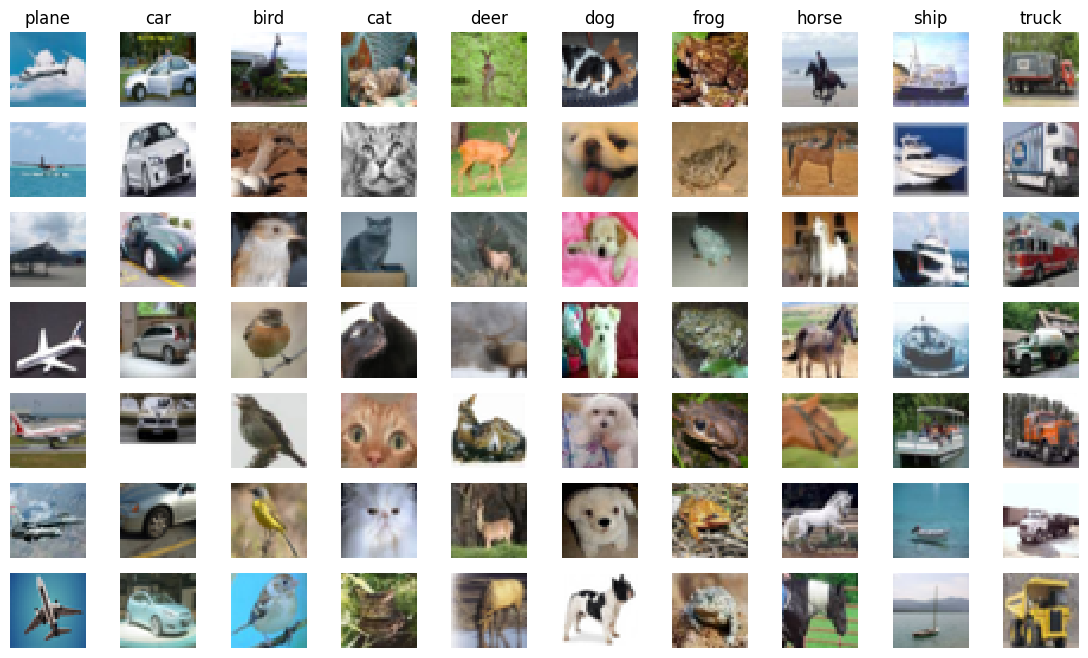

In [4]:
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = len(classes)
samples_per_class = 7

plt.figure(figsize=(14, 8))

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [5]:
num_training = 10000
num_test = 1000

mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (10000, 3072)
Train labels shape:  (10000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [6]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [7]:
y_test_pred = classifier.predict(X_test, k=1, num_loops=0)

print('Predicted labels:', y_test_pred[:20])
print('True labels     :', y_test[:20])

Predicted labels: [6. 8. 8. 8. 4. 4. 3. 2. 2. 8. 0. 0. 5. 7. 0. 8. 5. 3. 1. 7.]
True labels     : [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


(1000, 10000)


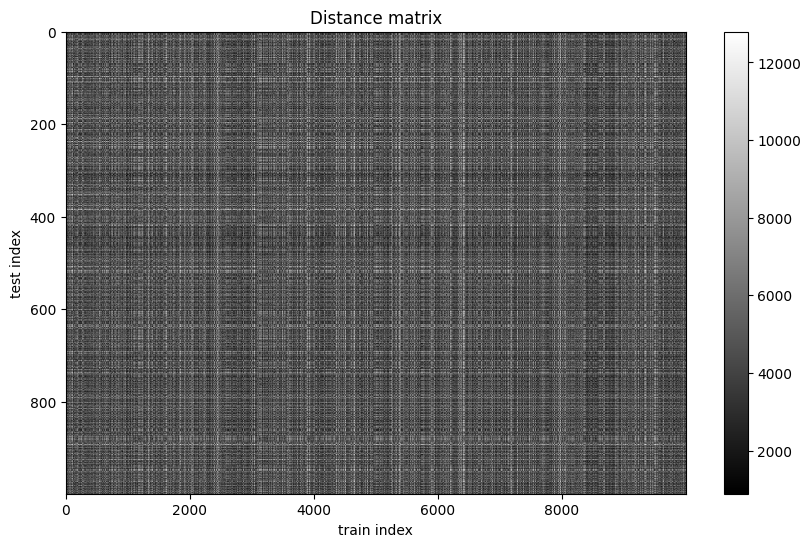

In [8]:
dists = classifier.compute_distances_no_loops(X_test)

print(dists.shape)

plt.figure(figsize=(10, 6))
plt.imshow(dists, interpolation='none', aspect='auto')
plt.colorbar()
plt.xlabel('train index')
plt.ylabel('test index')
plt.title('Distance matrix')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [9]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / len(y_test)

print(f'Got {num_correct} / {len(y_test)} correct => accuracy: {accuracy:.4f}')

Got 283 / 1000 correct => accuracy: 0.2830


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1: accuracy = 0.2830
k = 3: accuracy = 0.2800
k = 5: accuracy = 0.2960
k = 8: accuracy = 0.2760
k = 10: accuracy = 0.2880
k = 12: accuracy = 0.2850
k = 15: accuracy = 0.2890
k = 20: accuracy = 0.2970
k = 50: accuracy = 0.2690
k = 100: accuracy = 0.2670


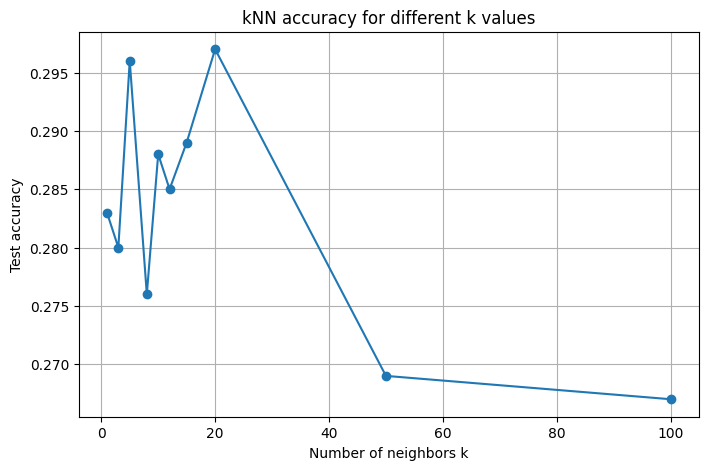

In [10]:
num_neighbors = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]
test_accuracy_values = []

for neighbor_count in num_neighbors:
    predicted_labels = classifier.predict(X_test, k=neighbor_count, num_loops=0)
    current_accuracy = np.mean(predicted_labels == y_test)
    test_accuracy_values.append(current_accuracy)
    print(f'k = {neighbor_count}: accuracy = {current_accuracy:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(num_neighbors, test_accuracy_values, marker='o')
plt.xlabel('Number of neighbors k')
plt.ylabel('Test accuracy')
plt.title('kNN accuracy for different k values')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [11]:
fold_count = 5
num_neighbors = [1, 3, 5, 8, 10, 12, 15, 20, 50]

X_train_folds = np.array_split(X_train, fold_count)
Y_train_folds = np.array_split(y_train, fold_count)

neighbor_to_scores = {}

for neighbor_count in num_neighbors:
    neighbor_to_scores[neighbor_count] = []

    for validation_fold_index in range(fold_count):
        validation_X = X_train_folds[validation_fold_index]
        validation_y = Y_train_folds[validation_fold_index]

        current_train_X = np.concatenate(
            [X_train_folds[i] for i in range(fold_count) if i != validation_fold_index],
            axis=0
        )
        current_train_y = np.concatenate(
            [Y_train_folds[i] for i in range(fold_count) if i != validation_fold_index],
            axis=0
        )

        knn_model = KNearestNeighbor()
        knn_model.train(current_train_X, current_train_y)

        predicted_validation_labels = knn_model.predict(
            validation_X,
            k=neighbor_count,
            num_loops=0
        )

        validation_accuracy = np.mean(predicted_validation_labels == validation_y)
        neighbor_to_scores[neighbor_count].append(validation_accuracy)

for neighbor_count in sorted(neighbor_to_scores):
    print(f'k = {neighbor_count}, accuracies = {neighbor_to_scores[neighbor_count]}')

k = 1, accuracies = [np.float64(0.2885), np.float64(0.284), np.float64(0.2825), np.float64(0.2745), np.float64(0.277)]
k = 3, accuracies = [np.float64(0.2875), np.float64(0.274), np.float64(0.2785), np.float64(0.2675), np.float64(0.2655)]
k = 5, accuracies = [np.float64(0.2945), np.float64(0.284), np.float64(0.2975), np.float64(0.275), np.float64(0.2785)]
k = 8, accuracies = [np.float64(0.2985), np.float64(0.296), np.float64(0.284), np.float64(0.274), np.float64(0.286)]
k = 10, accuracies = [np.float64(0.3025), np.float64(0.287), np.float64(0.284), np.float64(0.266), np.float64(0.285)]
k = 12, accuracies = [np.float64(0.3045), np.float64(0.2935), np.float64(0.2855), np.float64(0.265), np.float64(0.2755)]
k = 15, accuracies = [np.float64(0.294), np.float64(0.297), np.float64(0.275), np.float64(0.274), np.float64(0.276)]
k = 20, accuracies = [np.float64(0.2945), np.float64(0.299), np.float64(0.284), np.float64(0.272), np.float64(0.2795)]
k = 50, accuracies = [np.float64(0.2735), np.float


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [12]:
mean_scores = np.array([np.mean(neighbor_to_scores[k]) for k in num_neighbors])

for index, neighbor_count in enumerate(num_neighbors):
    print(
        f'k = {neighbor_count}, '
        f'mean accuracy = {mean_scores[index]:.4f}, '
    )

best_neighbor_count = num_neighbors[np.argmax(mean_scores)]
best_knn_model = KNearestNeighbor()
best_knn_model.train(X_train, y_train)

final_predicted_labels = best_knn_model.predict(X_test, k=best_neighbor_count, num_loops=0)
final_test_accuracy = np.mean(final_predicted_labels == y_test)

print(f'Best k = {best_neighbor_count}')
print(f'Test accuracy = {final_test_accuracy:.4f}')

k = 1, mean accuracy = 0.2813, 
k = 3, mean accuracy = 0.2746, 
k = 5, mean accuracy = 0.2859, 
k = 8, mean accuracy = 0.2877, 
k = 10, mean accuracy = 0.2849, 
k = 12, mean accuracy = 0.2848, 
k = 15, mean accuracy = 0.2832, 
k = 20, mean accuracy = 0.2858, 
k = 50, mean accuracy = 0.2729, 


Best k = 8
Test accuracy = 0.2760


1.11 Сделайте выводы по результатам 1 части задания.

Метод kNN показал ожидаемо умеренную точность (0.27–0.3), оптимальное значение параметра k = 8, выбрано по максимуму средней точности на кросс-валидации.

Подходит для изучения как базовый метод, но уступает в точности другим методам по работе с изображениями (например, SVM, нейросетевые классификаторы), так как не учитывает структуру изображений, работает напрямую с пикселями, плохо масштабируется.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [13]:
cifar10_dir = 'cifar-10-batches-py'

X_train_full, y_train_full, X_test_full, y_test_full = load_CIFAR10(cifar10_dir)

print('Full train data shape: ', X_train_full.shape)
print('Full train labels shape: ', y_train_full.shape)
print('Full test data shape: ', X_test_full.shape)
print('Full test labels shape: ', y_test_full.shape)

train_count = 49000
val_count = 1000
test_count = 1000
dev_count = 500

validation_indices = list(range(train_count, train_count + val_count))
X_val = X_train_full[validation_indices]
y_val = y_train_full[validation_indices]

train_indices = list(range(train_count))
X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]

dev_indices = np.random.choice(train_count, dev_count, replace=False)
X_dev = X_train[dev_indices]
y_dev = y_train[dev_indices]

test_indices = list(range(test_count))
X_test = X_test_full[test_indices]
y_test = y_test_full[test_indices]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print('Shapes after reshape:')
print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)
print('Dev:', X_dev.shape)

Full train data shape:  (50000, 32, 32, 3)
Full train labels shape:  (50000,)
Full test data shape:  (10000, 32, 32, 3)
Full test labels shape:  (10000,)
Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)
Dev data shape:  (500, 32, 32, 3)
Dev labels shape:  (500,)
Shapes after reshape:
Train: (49000, 3072)
Validation: (1000, 3072)
Test: (1000, 3072)
Dev: (500, 3072)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

In [14]:
# вычисляем среднее изображение по обучающей выборке
mean_image = np.mean(X_train, axis=0)
print('Mean image shape:', mean_image.shape)

# вычитаем среднее изображение из всех выборок
X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image
X_dev = X_dev - mean_image

# добавляем дополнительную размерность для учета свободного члена
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print('After preprocessing:')
print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)
print('Dev shape:', X_dev.shape)

Mean image shape: (3072,)
After preprocessing:
Train shape: (49000, 3073)
Validation shape: (1000, 3073)
Test shape: (1000, 3073)
Dev shape: (500, 3073)


2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [15]:
from scripts.classifiers.linear_svm import svm_loss_naive
import time

W = np.random.randn(3073, 10) * 0.0001

start_time = time.time()
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
end_time = time.time()

print('Naive loss:', loss)
print('Time:', end_time - start_time)

Naive loss: 8.810251082660807
Time: 0.04252791404724121



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [16]:

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -52.781120 analytic: -52.781120, relative error: 4.631488e-12
numerical: 14.958849 analytic: 14.958849, relative error: 1.673977e-11
numerical: 5.207037 analytic: 5.207037, relative error: 1.639494e-11
numerical: -40.559676 analytic: -40.559676, relative error: 7.690951e-12
numerical: 7.546940 analytic: 7.546940, relative error: 4.130651e-11
numerical: -1.577063 analytic: -1.577063, relative error: 8.411257e-11
numerical: -2.587974 analytic: -2.587974, relative error: 2.915556e-10
numerical: 10.332438 analytic: 10.332438, relative error: 3.210390e-11
numerical: -57.922552 analytic: -57.922552, relative error: 3.464357e-12
numerical: 9.379816 analytic: 9.379816, relative error: 2.643150e-11
numerical: 18.959048 analytic: 18.959048, relative error: 6.334023e-12
numerical: -4.932259 analytic: -4.932259, relative error: 7.480152e-12
numerical: -4.989150 analytic: -4.989150, relative error: 4.723814e-12
numerical: -1.721476 analytic: -1.721476, relative error: 3.423100e-11
numeri

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [18]:
from scripts.classifiers.linear_svm import svm_loss_vectorized

start_time = time.time()
naive_loss, naive_grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
naive_time = time.time() - start_time

start_time = time.time()
vectorized_loss, vectorized_grad = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
vectorized_time = time.time() - start_time

print('Naive loss: ', naive_loss)
print('Vectorized loss: ', vectorized_loss)
print('Loss difference: ', abs(naive_loss - vectorized_loss))
print('Gradient difference: ', np.linalg.norm(naive_grad - vectorized_grad, ord='fro'))
print('Naive time: ', naive_time)
print('Vectorized time: ', vectorized_time)

Naive loss:  8.810251082660807
Vectorized loss:  8.81025108266078
Loss difference:  2.6645352591003757e-14
Gradient difference:  1.2404396257944374e-11
Naive time:  0.044985055923461914
Vectorized time:  0.0032835006713867188


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [19]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 785.839463
iteration 100 / 1500: loss 286.311010
iteration 200 / 1500: loss 107.542787
iteration 300 / 1500: loss 42.453365
iteration 400 / 1500: loss 18.905554
iteration 500 / 1500: loss 9.948496
iteration 600 / 1500: loss 7.575048
iteration 700 / 1500: loss 5.883896
iteration 800 / 1500: loss 5.283709
iteration 900 / 1500: loss 5.009099
iteration 1000 / 1500: loss 5.280840
iteration 1100 / 1500: loss 5.306723
iteration 1200 / 1500: loss 4.789870
iteration 1300 / 1500: loss 5.404580
iteration 1400 / 1500: loss 5.145511
That took 2.659327s


In [20]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.367347
validation accuracy: 0.387000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [21]:
from scripts.classifiers import LinearSVM

results = {}
best_validation_accuracy = -1
best_svm_model = None

learning_rate_values = [1e-7, 5e-7, 1e-6]
regularization_values = [2.5e4, 5e4, 1e5]

for learning_rate in learning_rate_values:
    for regularization_strength in regularization_values:
        current_svm_model = LinearSVM()

        current_svm_model.train(
            X_train,
            y_train,
            learning_rate=learning_rate,
            reg=regularization_strength,
            num_iters=1500,
            batch_size=200,
            verbose=False
        )

        current_train_predictions = current_svm_model.predict(X_train)
        current_train_accuracy = np.mean(current_train_predictions == y_train)

        current_validation_predictions = current_svm_model.predict(X_val)
        current_validation_accuracy = np.mean(current_validation_predictions == y_val)

        results[(learning_rate, regularization_strength)] = (
            current_train_accuracy,
            current_validation_accuracy
        )

        if current_validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = current_validation_accuracy
            best_svm_model = current_svm_model

In [22]:
for (learning_rate, regularization_strength) in sorted(results):
    train_accuracy, validation_accuracy = results[(learning_rate, regularization_strength)]
    print(
        'learning rate = %e, reg = %e, train accuracy = %f, validation accuracy = %f'
        % (learning_rate, regularization_strength, train_accuracy, validation_accuracy)
    )

print('Best validation accuracy:', best_validation_accuracy)

learning rate = 1.000000e-07, reg = 2.500000e+04, train accuracy = 0.367918, validation accuracy = 0.375000
learning rate = 1.000000e-07, reg = 5.000000e+04, train accuracy = 0.363061, validation accuracy = 0.377000
learning rate = 1.000000e-07, reg = 1.000000e+05, train accuracy = 0.339796, validation accuracy = 0.353000
learning rate = 5.000000e-07, reg = 2.500000e+04, train accuracy = 0.307939, validation accuracy = 0.324000
learning rate = 5.000000e-07, reg = 5.000000e+04, train accuracy = 0.309714, validation accuracy = 0.324000
learning rate = 5.000000e-07, reg = 1.000000e+05, train accuracy = 0.317633, validation accuracy = 0.319000
learning rate = 1.000000e-06, reg = 2.500000e+04, train accuracy = 0.258429, validation accuracy = 0.265000
learning rate = 1.000000e-06, reg = 5.000000e+04, train accuracy = 0.249694, validation accuracy = 0.284000
learning rate = 1.000000e-06, reg = 1.000000e+05, train accuracy = 0.230571, validation accuracy = 0.215000
Best validation accuracy: 0.

In [23]:
test_predictions = best_svm_model.predict(X_test)
test_accuracy = np.mean(test_predictions == y_test)

print('Final SVM test accuracy:', test_accuracy)

Final SVM test accuracy: 0.364


2.9 Сделайте выводы по второй части задания

SVM показал более высокую точность (0.36-0.38) по сравнению с kNN (0.27-0.3), что связано с использованием обучаемых весов и более эффективной моделью разделения классов, хотя точность всё ещё невысокая из-за применения линейного метода к нелинейным закономерностям в изображениях. 

Функция потерь и градиент были реализованы в двух вариантах — naive и vectorized. Корректность вычисления градиента подтверждена с помощью численной проверки. Оптимальные параметры были выбраны по validation-выборке.

В процессе обучения наблюдается устойчивое снижение функции потерь, что свидетельствует о корректной работе алгоритма оптимизации.

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [ ]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image



X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

3.4 Реализуйте функции в classifiers/softmax.py




In [ ]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [ ]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [ ]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [ ]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

3.10 Сделайте выводы по третьей части задания